In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

In [2]:
# Discretization
d = 0.08
n = 20
x = np.linspace(0, d, n+2)  # 20 interior nodes + 2 boundaries
dx = x[1] - x[0]
x = x[1:-1]

In [3]:
# General parameters
ho = 10         # W/m2K
hi = 1200       # W/m2K
Ta = 15 + 273.15  # K
k  = 15         # W/mK

# Reactor parameters
A = 3           # m2
m = 800         # kg
cpl = 4160      # J/kg*K
alpha = 3.95e-6 # AISI 304
epsilon = 0.98

In [4]:
# Balance at the outer interface: conduction = convection + radiation
def ecrad(T, Tn1, Tn2):
    # Second-order backward finite difference for the first derivative
    return -k*(3*T - 4*Tn1 + Tn2)/(2*dx) - ho*(T - Ta) - epsilon*5.67e-8*(T**4 - Ta**4)

In [5]:
# Differential model
def modelo(t, T):
    # Initialize nodes: n + 1 (internal wall nodes + fluid)
    dT = np.empty(n+1)
    
    # First wall node: convection = conduction
    Tbi = (2*dx*hi*T[0] + 4*k*T[2] - k*T[3])/(2*dx*hi + 3*k)
    
    # Last wall node: conduction = convection + radiation
    [Tbd] = fsolve(ecrad, 350, args=(T[-1], T[-2]), xtol=1e-9)
    
    # ODE for the fluid
    dT[0] = -hi*A*(T[0] - Tbi)/(m*cpl)
    
    # ODEs for interior wall nodes
    for ec in range(1, n+1):
        if 1 < ec < n:
            # Central difference for the second derivative
            dT[ec] = alpha*(T[ec+1] - 2*T[ec] + T[ec-1])/dx**2
        elif ec == 1:
            # First interior node uses boundary condition Tbi
            dT[ec] = alpha*(T[ec+1] - 2*T[ec] + Tbi)/dx**2            
        elif ec == n:
            # Last interior node uses boundary condition Tbd
            dT[ec] = alpha*(Tbd - 2*T[ec] + T[ec-1])/dx**2    
    return dT

In [6]:
# Model integration
Twall0 = 30     # °C
Tfluid0 = 150   # °C
T0 = np.array([Tfluid0] + [Twall0]*n) + 273.15
sol = solve_ivp(modelo, (0, 3600*2), T0, method='BDF', rtol=1e-9)
T = sol.y

# Dimensionality
print(f"The solution t has {sol.t.shape[0]} rows.")
print(f"The solution T has {T.shape[0]} rows (nodes) and {T.shape[1]} columns (time).")

# Compute fluid–wall (Tci) and wall–air (Tcd) interface temperatures
Tci = (2*dx*hi*T[0] + 4*k*T[2] - k*T[3])/(2*dx*hi + 3*k)  # inner face
Tcd = np.empty(T.shape[1])
for dt in range(T.shape[1]):
    [Tcd[dt]] = fsolve(ecrad, 310, args=(T[-1,dt], T[-2,dt]), xtol=1e-9)  # outer face

The solution t has 277 rows.
The solution T has 21 rows (nodes) and 277 columns (time).


In [7]:
# Part (b): Interpolate interface temperatures at t = 1000 s
Tci_1000 = np.interp(1000, sol.t, Tci)   # inner face
Tcd_1000 = np.interp(1000, sol.t, Tcd)   # outer face
print("The temperature difference between both faces is",
      round(Tci_1000 - Tcd_1000, 1), "°C.")

The temperature difference between both faces is 25.6 °C.


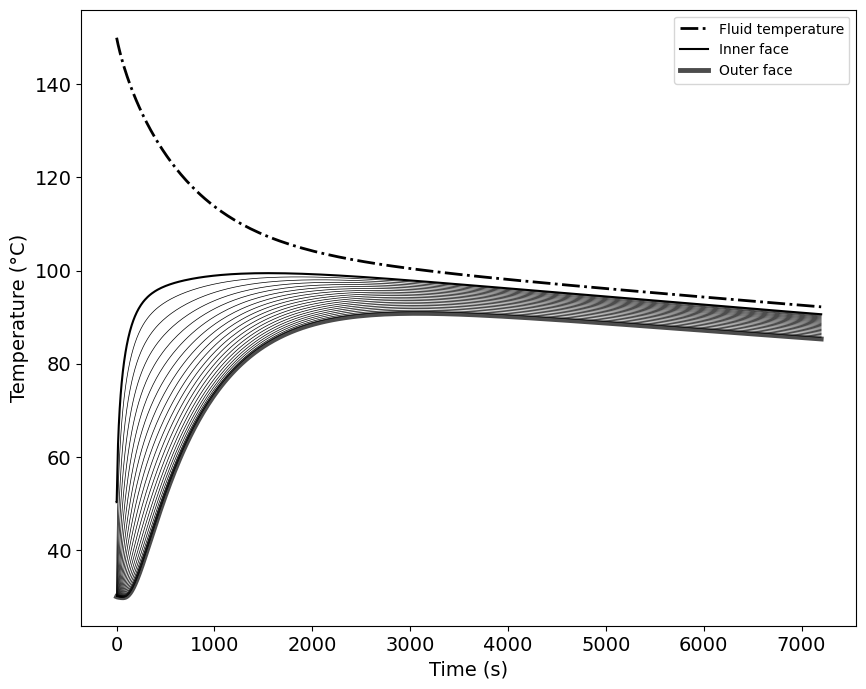

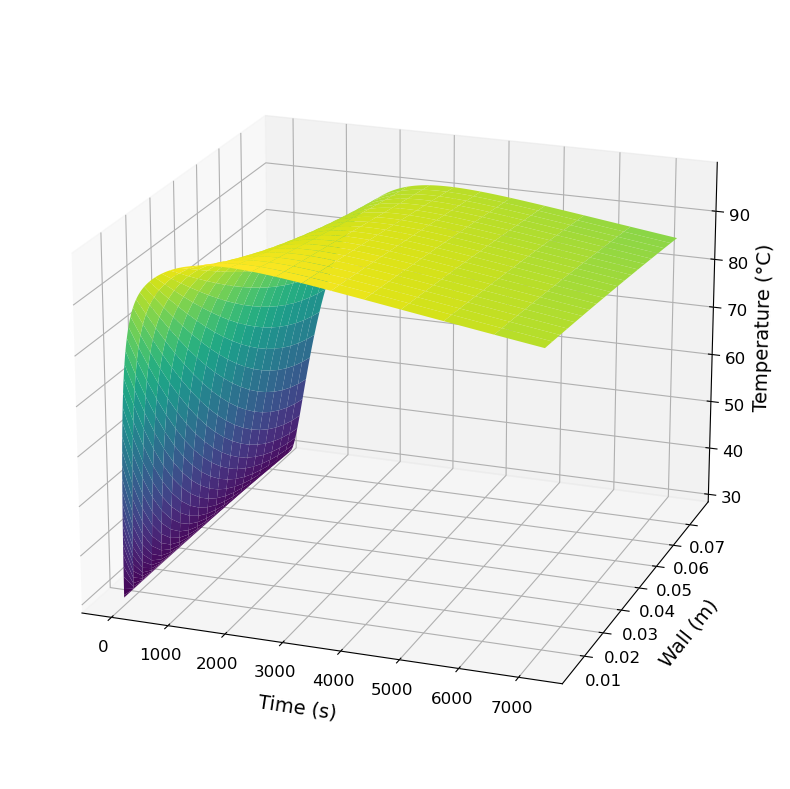

In [8]:
# Figures
# Figure 1: temperature profiles for fluid + wall nodes
T = T - 273.15
Tf = T[0]       # fluid temperature
T = T[1:, :]    # internal wall nodes

fig = plt.figure(figsize=(10, 8))
plt.plot(sol.t, Tf, color='k', ls='-.', lw=2, label='Fluid temperature')
plt.plot(sol.t, T.T, color='k', lw=0.5)
plt.plot(sol.t, Tci - 273.15, color='k', lw=1.5, label='Inner face')
plt.plot(sol.t, Tcd - 273.15, color='k', alpha=0.7, lw=3.5, label='Outer face')
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=10)

# Figure 2: 3D temperature distribution in the wall
Tm, X = np.meshgrid(sol.t, x)

fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Tm, X, T, cmap='viridis', edgecolor='none')
ax.set_xlabel('Time (s)', fontsize=14, labelpad=10)
ax.set_ylabel('Wall (m)', fontsize=14, labelpad=10)
ax.set_zlabel('Temperature (°C)', fontsize=14)
plt.tick_params(axis='both', labelsize=12)
ax.view_init(azim=290, elev=20)
fig.tight_layout()

plt.show()